# LBP + SVM — Baseline модель

Класичний підхід до face anti-spoofing.
Використовує Local Binary Patterns як дескриптор текстури + SVM класифікатор.

**Вхід:** кадри з `datasets/frames/` (після запуску preprocessing.ipynb)

**Виходи:**
- `models/lbp_svm_model.pkl`
- EER, HTER, AUC на test set по всіх протоколах

## Імпорти

In [12]:
import os
import numpy as np
import cv2
from pathlib import Path
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Бібліотеки завантажено')

Бібліотеки завантажено


## Конфігурація

In [13]:
DATASET_ROOT = Path('./datasets')
FRAMES_ROOT  = Path('./datasets/frames')
MODELS_DIR   = Path('./models')
MODELS_DIR.mkdir(exist_ok=True)

LBP_POINTS = 8
LBP_RADIUS = 1

PROTOCOLS = {
    'grandtest': ('attack-grandtest-allsupports-{}.txt', 'real-{}.txt'),
    'print':     ('attack-print-allsupports-{}.txt',     'real-{}.txt'),
    'mobile':    ('attack-mobile-allsupports-{}.txt',    'real-{}.txt'),
    'highdef':   ('attack-highdef-allsupports-{}.txt',   'real-{}.txt'),
    'fixed':     ('attack-grandtest-fixed-{}.txt',       'real-{}.txt'),
    'hand':      ('attack-grandtest-hand-{}.txt',        'real-{}.txt'),
}
print(f'Dataset: {DATASET_ROOT.resolve()}')

Dataset: /Users/darwin/edu/cnn-face-antispoofing-2d/datasets


## LBP дескриптор

In [17]:
class LBPDescriptor:
    def __init__(self, num_points=8, radius=1):
        self.num_points = num_points
        self.radius = radius
        self.n_bins = num_points * (num_points - 1) + 3

    def _is_uniform(self, code):
        transitions = 0
        for i in range(self.num_points):
            b1 = (code >> i) & 1
            b2 = (code >> ((i + 1) % self.num_points)) & 1
            if b1 != b2:
                transitions += 1
        return transitions <= 2

    def extract(self, image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        gray = gray.astype(np.float32)
        lbp_map = np.zeros(gray.shape, dtype=np.int32)
        angles = 2 * np.pi * np.arange(self.num_points) / self.num_points
        for i, angle in enumerate(angles):
            nx = int(round(self.radius * np.cos(angle)))
            ny = int(round(-self.radius * np.sin(angle)))
            shifted = np.roll(np.roll(gray, ny, axis=0), nx, axis=1)
            lbp_map += ((shifted >= gray).astype(np.int32)) << i
        hist = np.zeros(self.n_bins, dtype=np.float32)
        bin_idx = 0
        for code in range(2 ** self.num_points):
            if self._is_uniform(code):
                hist[bin_idx] = np.sum(lbp_map == code)
                bin_idx += 1
            else:
                hist[-1] += np.sum(lbp_map == code)
        total = hist.sum()
        if total > 0:
            hist /= total
        return hist

lbp = LBPDescriptor(LBP_POINTS, LBP_RADIUS)
print(f'LBP: {LBP_POINTS} points, radius={LBP_RADIUS}, {lbp.n_bins} bins')

LBP: 8 points, radius=1, 59 bins


## Функції завантаження даних

In [18]:
def read_protocol(proto_file):
    if not Path(proto_file).exists():
        print(f'[!] Не знайдено: {proto_file}')
        return []
    with open(proto_file) as f:
        return [l.strip() for l in f if l.strip()]

def video_to_frames_dir(video_rel_path):
    p = Path(video_rel_path)
    return FRAMES_ROOT / p.parent / p.stem

def load_features(video_paths, label, extractor, desc=''):
    X, y, groups = [], [], []
    for i, vp in enumerate(tqdm(video_paths, desc=desc, leave=False)):
        frames_dir = video_to_frames_dir(vp)
        frame_files = sorted(frames_dir.glob('*.jpg')) if frames_dir.exists() else []
        for fp in frame_files:
            img = cv2.imread(str(fp))
            if img is None:
                continue
            X.append(extractor.extract(img))
            y.append(label)
            groups.append(i)
    return np.array(X), np.array(y), np.array(groups)

print('Функції готові')

Функції готові


## Train — екстракція ознак та навчання SVM

In [19]:
PROTO_DIR = DATASET_ROOT / 'protocols'

train_real   = read_protocol(PROTO_DIR / 'real-train.txt')
train_attack = read_protocol(PROTO_DIR / 'attack-grandtest-allsupports-train.txt')
print(f'Train: {len(train_real)} real, {len(train_attack)} attack')

Xr, yr, gr = load_features(train_real,   0, lbp, 'train/real')
Xa, ya, ga = load_features(train_attack, 1, lbp, 'train/attack')

X_train = np.vstack([Xr, Xa])
y_train = np.concatenate([yr, ya])
print(f'Всього кадрів: {len(X_train)}, ознак: {X_train.shape[1]}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print('Навчання SVM (class_weight="balanced" — компенсує дисбаланс 1:5)...')
svm = SVC(kernel='rbf', C=10.0, gamma='scale', probability=True,
          class_weight='balanced', random_state=42)
svm.fit(X_train_scaled, y_train)
print(f'Train accuracy: {accuracy_score(y_train, svm.predict(X_train_scaled)):.4f}')


Train: 60 real, 300 attack


Всього кадрів: 3575, ознак: 59
Навчання SVM (class_weight="balanced" — компенсує дисбаланс 1:5)...
Train accuracy: 0.9997


## Утиліти оцінки

In [20]:
def aggregate_to_video(frame_scores, groups, y):
    v_scores, v_labels = [], []
    for g in np.unique(groups):
        mask = groups == g
        v_scores.append(frame_scores[mask].mean())
        v_labels.append(y[mask][0])
    return np.array(v_scores), np.array(v_labels)

def compute_eer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2), float(thresholds[idx])

def compute_hter(y_true, y_scores, threshold):
    preds = (y_scores >= threshold).astype(int)
    far = preds[y_true == 0].mean()
    frr = (1 - preds[y_true == 1]).mean()
    return float((far + frr) / 2)

print('Утиліти готові')

Утиліти готові


## Підбір порогу на devel set

In [21]:
# Baseline: threshold на grandtest-devel (для контексту; у eval_protocol рахуємо threshold для кожного під-протоколу окремо)
devel_real   = read_protocol(PROTO_DIR / 'real-devel.txt')
devel_attack = read_protocol(PROTO_DIR / 'attack-grandtest-allsupports-devel.txt')

Xdr, ydr, gdr = load_features(devel_real,   0, lbp, 'devel/real')
Xda, yda, gda = load_features(devel_attack, 1, lbp, 'devel/attack')

Xd = np.vstack([Xdr, Xda])
yd = np.concatenate([ydr, yda])
gd = np.concatenate([gdr, gda + len(np.unique(gdr))])

devel_scores = svm.predict_proba(scaler.transform(Xd))[:, 1]
vs_d, vl_d  = aggregate_to_video(devel_scores, gd, yd)
eer_d, grandtest_threshold = compute_eer(vl_d, vs_d)

print(f'Grandtest Devel EER: {eer_d*100:.2f}%  |  Threshold: {grandtest_threshold:.4f}')
print('(цей threshold — для контексту; кожен під-протокол у eval_protocol матиме свій окремий)')


Grandtest Devel EER: 10.50%  |  Threshold: 0.7415
(цей threshold — для контексту; кожен під-протокол у eval_protocol матиме свій окремий)


## Оцінка на test set по всіх протоколах

In [22]:
def get_devel_scores(atk_tpl, real_tpl, proto_name):
    """Повертає video-level scores на devel-підмножині конкретного під-протоколу."""
    attack_paths = read_protocol(PROTO_DIR / atk_tpl.format('devel'))
    real_paths   = read_protocol(PROTO_DIR / real_tpl.format('devel'))
    if not attack_paths or not real_paths:
        return None, None
    Xr, yr, gr = load_features(real_paths,   0, lbp, f'{proto_name}/devel/real')
    Xa, ya, ga = load_features(attack_paths, 1, lbp, f'{proto_name}/devel/attack')
    X = np.vstack([Xr, Xa])
    y = np.concatenate([yr, ya])
    g = np.concatenate([gr, ga + len(np.unique(gr))])
    scores = svm.predict_proba(scaler.transform(X))[:, 1]
    return aggregate_to_video(scores, g, y)


def eval_protocol(proto_name, atk_tpl, real_tpl, split='test'):
    # --- 1. Threshold з devel-множини цього ж під-протоколу ---
    vs_d, vl_d = get_devel_scores(atk_tpl, real_tpl, proto_name)
    if vs_d is None:
        return None
    _, proto_threshold = compute_eer(vl_d, vs_d)

    # --- 2. Test ---
    attack_paths = read_protocol(PROTO_DIR / atk_tpl.format(split))
    real_paths   = read_protocol(PROTO_DIR / real_tpl.format(split))
    if not attack_paths or not real_paths:
        return None
    Xr, yr, gr = load_features(real_paths,   0, lbp, f'{proto_name}/real')
    Xa, ya, ga = load_features(attack_paths, 1, lbp, f'{proto_name}/attack')
    X = np.vstack([Xr, Xa])
    y = np.concatenate([yr, ya])
    g = np.concatenate([gr, ga + len(np.unique(gr))])
    scores = svm.predict_proba(scaler.transform(X))[:, 1]
    vs, vl = aggregate_to_video(scores, g, y)
    eer, _ = compute_eer(vl, vs)
    hter   = compute_hter(vl, vs, proto_threshold)
    fpr, tpr, _ = roc_curve(vl, vs)
    return {
        'protocol': proto_name, 'n': len(np.unique(g)),
        'acc': accuracy_score(vl, (vs >= proto_threshold).astype(int)),
        'auc': auc(fpr, tpr), 'eer': eer, 'hter': hter,
        'threshold': proto_threshold,
        'fpr': fpr, 'tpr': tpr, 'vs': vs, 'vl': vl
    }

print('Оцінка test set (окремий threshold для кожного під-протоколу)...')
results = {}
for name, (atk, real) in PROTOCOLS.items():
    print(f'  {name}...')
    r = eval_protocol(name, atk, real)
    if r is not None:
        results[name] = r
        print(f'    threshold={r["threshold"]:.4f}  EER={r["eer"]*100:.2f}%  HTER={r["hter"]*100:.2f}%')


Оцінка test set (окремий threshold для кожного під-протоколу)...
  grandtest...


    threshold=0.7415  EER=6.90%  HTER=5.77%
  print...


    threshold=0.9276  EER=2.50%  HTER=3.75%
  mobile...


    threshold=0.9445  EER=3.15%  HTER=3.81%
  highdef...


    threshold=0.5502  EER=9.69%  HTER=10.00%
  fixed...


    threshold=0.8669  EER=7.05%  HTER=5.68%
  hand...


    threshold=0.7446  EER=5.50%  HTER=5.75%


## Таблиця результатів

In [9]:
print('\n' + '='*60)
print(f'{"Протокол":<12} {"N":>5} {"Acc":>7} {"AUC":>7} {"EER%":>7} {"HTER%":>8}')
print('-'*60)
for name, r in results.items():
    print(f'{name:<12} {r["n"]:>5} {r["acc"]:>7.4f} {r["auc"]:>7.4f} '
          f'{r["eer"]*100:>6.2f}% {r["hter"]*100:>7.2f}%')
print('='*60)


Протокол         N     Acc     AUC    EER%    HTER%
------------------------------------------------------------
grandtest      477  0.9371  0.9859   6.90%    5.77%
print          160  0.9625  0.9950   2.50%    3.75%
mobile         237  0.9536  0.9972   3.15%    3.81%
highdef        240  0.9125  0.9703   9.69%   10.00%
fixed          277  0.9350  0.9865   7.05%    5.68%
hand           280  0.9393  0.9853   5.50%    5.75%


## ROC криві

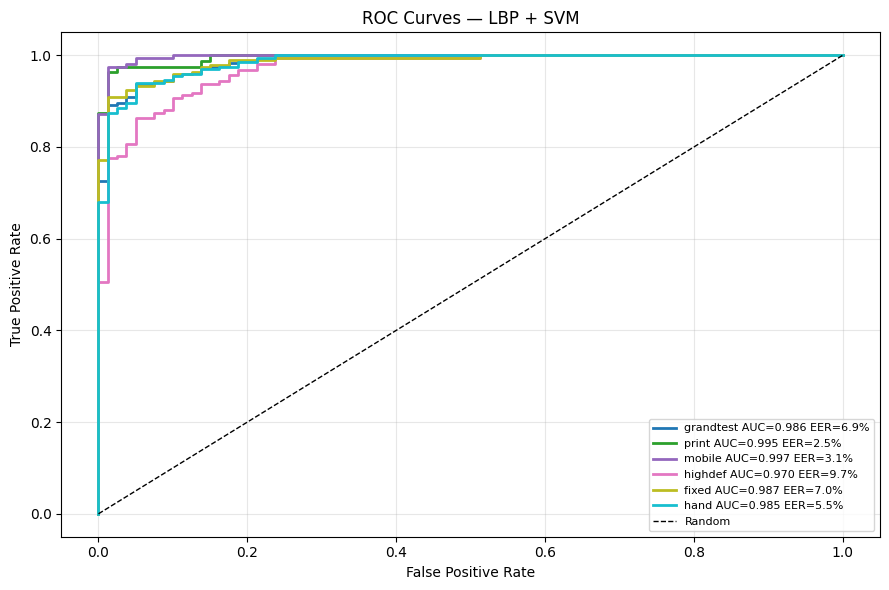

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), c in zip(results.items(), colors):
    ax.plot(r['fpr'], r['tpr'], color=c, lw=2,
            label=f'{name} AUC={r["auc"]:.3f} EER={r["eer"]*100:.1f}%')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — LBP + SVM'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('models/lbp_svm_roc.png', dpi=150)
plt.show()

## Confusion Matrix (grandtest)

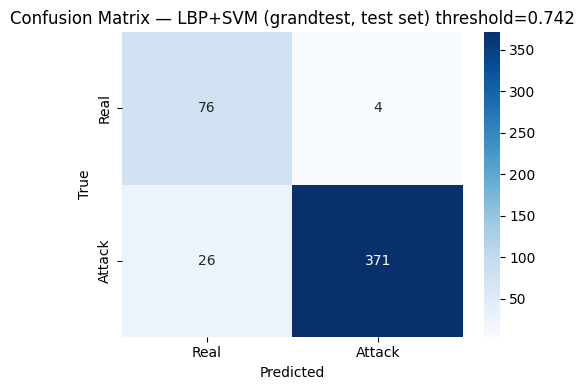

In [11]:
from sklearn.metrics import confusion_matrix
r = results['grandtest']
preds = (r['vs'] >= r['threshold']).astype(int)
cm = confusion_matrix(r['vl'], preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Attack'], yticklabels=['Real','Attack'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — LBP+SVM (grandtest, test set) threshold={r["threshold"]:.3f}')
plt.tight_layout()
plt.savefig('models/lbp_svm_cm.png', dpi=150)
plt.show()


## Збереження моделі

In [ ]:
# Threshold тепер зберігається всередині кожного results[protocol]['threshold']
model_data = {
    'svm': svm, 'scaler': scaler,
    'lbp_params': {'num_points': LBP_POINTS, 'radius': LBP_RADIUS},
    'results': {k: {m: v for m, v in r.items() if m not in ('fpr','tpr','vs','vl')}
                for k, r in results.items()}
}
save_path = MODELS_DIR / 'lbp_svm_model.pkl'
joblib.dump(model_data, save_path)
print(f'Модель збережено: {save_path}')
